In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/.DS_Store
./kaggle/input/deep-learning-course-midterm/test.csv
./kaggle/input/deep-learning-course-midterm/train.csv
./kaggle/input/deep-learning-course-midterm/sample_submission.csv


# Import

In [2]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import tqdm
import numpy as np
import time
import json
import random
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import glob

# EDA

In [3]:
DATA_PATH = Path('./kaggle/input/deep-learning-course-midterm')
data_files = glob.glob(str(DATA_PATH / '*.csv'))
data_files

['kaggle/input/deep-learning-course-midterm/test.csv',
 'kaggle/input/deep-learning-course-midterm/train.csv',
 'kaggle/input/deep-learning-course-midterm/sample_submission.csv']

## Train dataset

In [4]:
df = pd.read_csv(DATA_PATH / 'train.csv', index_col='id')
df

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
id,,,,,,,,,,,,,,,,,,,,,
1,I13,N,256.0,257.0,-0.025436,-0.369672,1.529989,-0.619057,-0.079256,17.0,...,-0.036850,5.0,2.0,15.0,8.0,-0.036850,-0.175291,-0.343045,-0.511080,-0.644588
2,867,N,91.0,101.0,0.005207,0.205958,-0.005508,-0.512249,-0.005508,4.0,...,-0.062579,18.0,1.0,23.0,4.0,-0.062579,0.034085,0.166282,0.677930,-0.205569
3,106,N,291.0,287.0,0.347613,1.470143,1.424123,1.424123,-0.090802,21.0,...,-0.052524,2.0,5.0,15.0,8.0,-0.052524,-0.052524,-0.052524,-0.050269,-0.050269
4,49.0,N,274.0,278.0,0.023990,0.878232,0.815362,0.815362,-0.032605,27.0,...,-0.107051,1.0,5.0,14.0,8.0,-0.107051,-0.107051,-0.107051,-0.107051,-0.107051
5,34.0,N,242.0,242.0,0.092220,1.011302,-0.078682,-0.078682,-0.078682,0.0,...,-0.010008,19.0,3.0,27.0,5.0,-0.010008,0.004223,0.115988,0.164468,-0.013203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770919,219,N,377.0,197.0,-0.016626,-0.582910,1.981005,-1.133824,-0.072954,26.0,...,-0.024641,13.0,7.0,22.0,2.0,-0.024641,-0.004937,0.121826,0.273290,0.540792
770920,855,N,100.0,89.0,0.010551,-0.070620,0.670927,-0.611026,0.002371,8.0,...,-0.008911,5.0,2.0,11.0,4.0,-0.008911,-0.055511,-0.162345,-0.333680,-0.496377
770921,I56,N,297.0,292.0,-0.063508,0.381688,-0.068533,-0.796180,-0.244079,14.0,...,-0.370784,4.0,6.0,23.0,13.0,-0.370784,-0.370784,-0.491312,-0.584153,-0.636181


In [5]:
df.shape

(770923, 34)

In [6]:
df.columns

Index(['record', 'type', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 770923 entries, 1 to 770923
Data columns (total 34 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          709850 non-null  object 
 1   type            709850 non-null  object 
 2   0_pre-RR        709850 non-null  float64
 3   0_post-RR       709850 non-null  float64
 4   0_pPeak         709850 non-null  float64
 5   0_tPeak         709850 non-null  float64
 6   0_rPeak         709850 non-null  float64
 7   0_sPeak         709850 non-null  float64
 8   0_qPeak         709850 non-null  float64
 9   0_qrs_interval  709850 non-null  float64
 10  0_pq_interval   709850 non-null  float64
 11  0_qt_interval   709850 non-null  float64
 12  0_st_interval   709850 non-null  float64
 13  0_qrs_morph0    709850 non-null  float64
 14  0_qrs_morph1    709850 non-null  float64
 15  0_qrs_morph2    709850 non-null  float64
 16  0_qrs_morph3    709850 non-null  float64
 17  0_qrs_morph4   

In [8]:
df.dtypes[df.dtypes == 'object']

record    object
type      object
dtype: object

All of the features needed are numerical, except the record (which we will remove later), and type (our target label)

In [9]:
df.describe()

,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,0_pq_interval,0_qt_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
count,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,709850.000000,...,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000,631220.000000
mean,201.009236,201.059607,0.058705,0.438354,0.524657,-0.374096,-0.126095,17.876041,9.843125,45.067042,...,-0.199521,8.542500,8.444831,27.738696,10.751366,-0.199521,-0.207515,-0.215045,-0.231361,-0.355536
std,79.698682,80.701501,0.189891,0.655704,0.756126,0.695246,0.276728,13.897318,9.511780,34.983029,...,0.267963,9.437241,7.374284,15.446795,7.289246,0.267963,0.282529,0.374879,0.463753,0.452984
min,2.000000,0.000000,-4.208601,-7.959463,-7.113196,-7.971319,-7.113196,0.000000,1.000000,2.000000,...,-5.481982,0.000000,1.000000,2.000000,1.000000,-5.481982,-4.013603,-4.013603,-3.991484,-4.520327
25%,140.000000,140.000000,-0.027872,-0.020488,-0.027783,-0.693473,-0.141755,7.000000,4.000000,21.000000,...,-0.269285,3.000000,3.000000,17.000000,5.000000,-0.269285,-0.300047,-0.386092,-0.473039,-0.557039
50%,202.000000,202.000000,0.024152,0.220803,0.422011,-0.359345,-0.074300,16.000000,7.000000,35.000000,...,-0.125602,5.000000,6.000000,25.000000,9.000000,-0.125602,-0.151812,-0.207980,-0.256680,-0.334428
75%,258.000000,258.000000,0.100098,0.954564,0.962760,-0.030453,-0.029080,26.000000,14.000000,51.000000,...,-0.032971,11.000000,12.000000,36.000000,16.000000,-0.032971,-0.022679,0.013066,0.042724,-0.070460
max,2228.000000,10964.000000,10.565904,4.633166,4.598265,4.018918,3.129033,203.000000,150.000000,334.000000,...,4.033554,260.000000,185.000000,400.000000,177.000000,4.033554,3.585718,4.002332,3.755566,3.575504


## Check missing values

In [10]:
df.isnull().sum().sort_values(ascending=False)

1_qrs_morph4      139703
1_qrs_interval    139703
1_post-RR         139703
1_pPeak           139703
1_tPeak           139703
1_rPeak           139703
1_sPeak           139703
1_qPeak           139703
1_pq_interval     139703
1_qt_interval     139703
1_st_interval     139703
1_qrs_morph0      139703
1_qrs_morph1      139703
1_qrs_morph2      139703
1_qrs_morph3      139703
1_pre-RR          139703
type               61073
record             61073
0_qrs_morph3       61073
0_qrs_morph2       61073
0_qrs_morph1       61073
0_qrs_morph0       61073
0_st_interval      61073
0_qt_interval      61073
0_pq_interval      61073
0_qrs_interval     61073
0_qPeak            61073
0_sPeak            61073
0_rPeak            61073
0_tPeak            61073
0_pPeak            61073
0_post-RR          61073
0_pre-RR           61073
0_qrs_morph4       61073
dtype: int64

<Axes: >

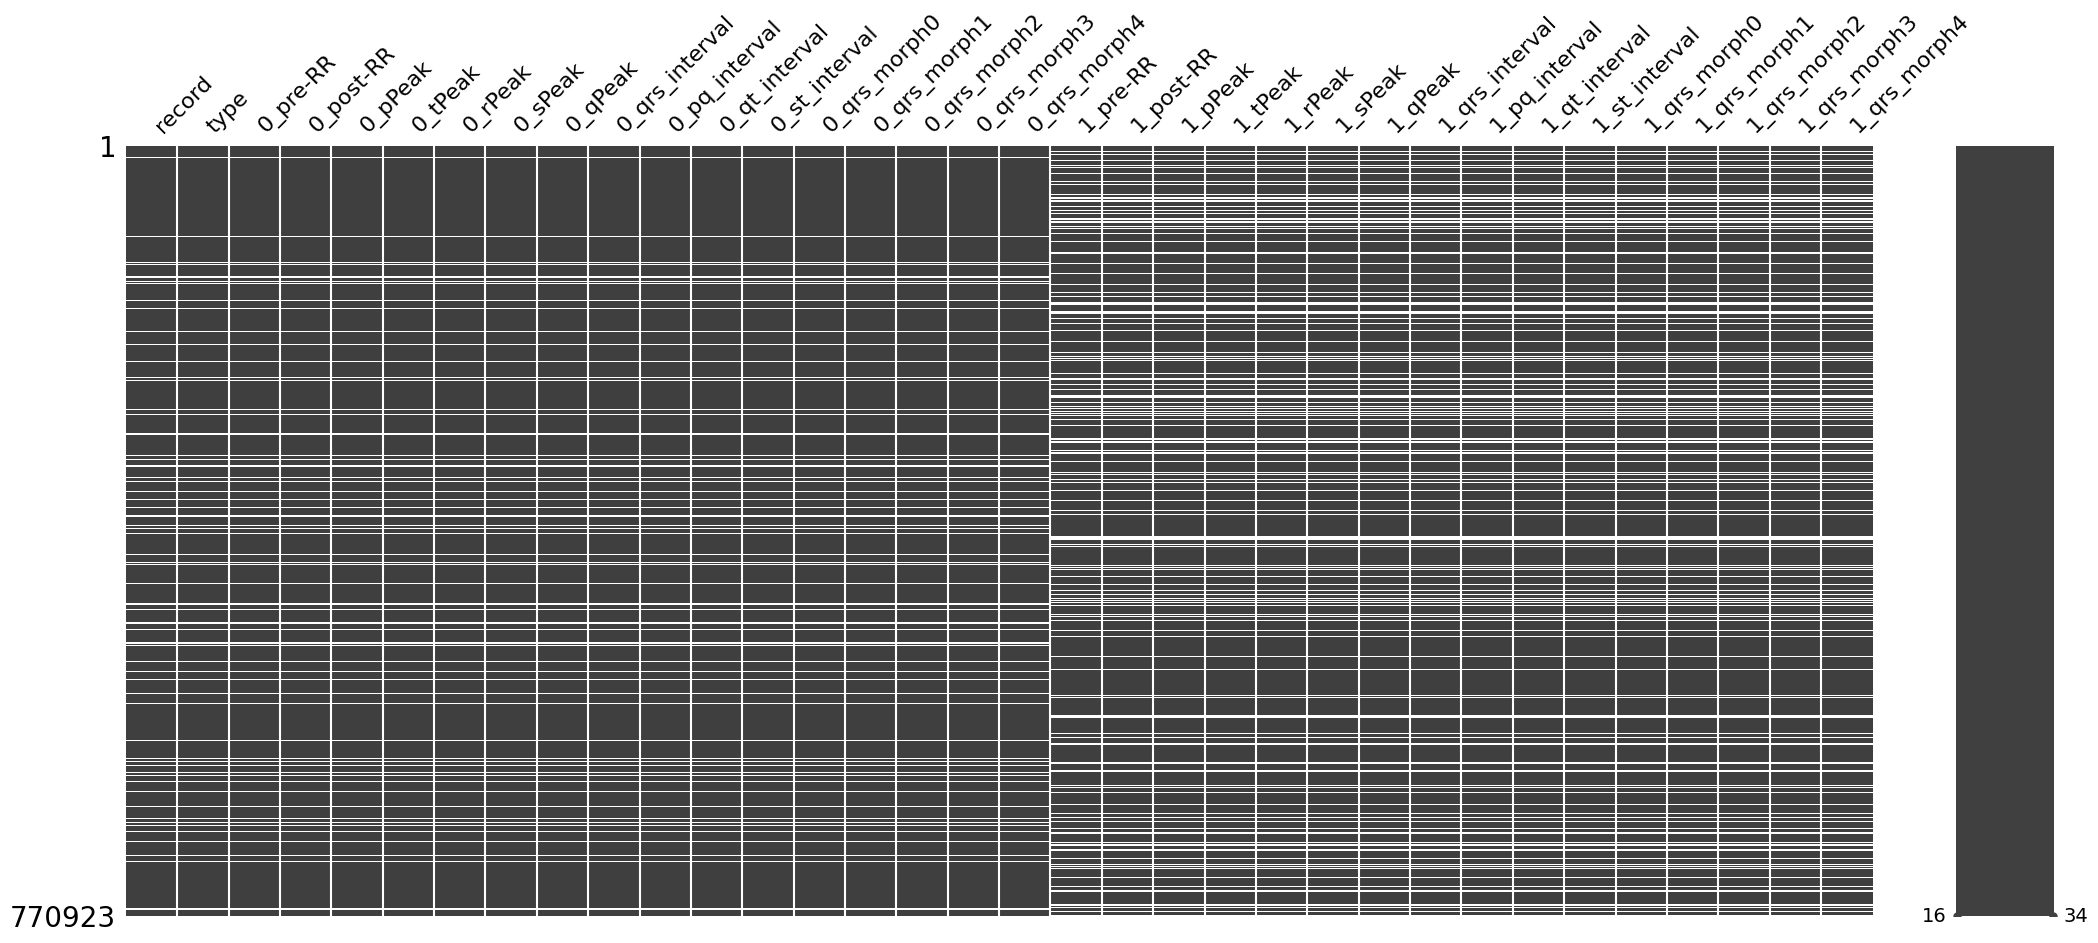

In [11]:
msno.matrix(df)

Most of the missing values don't have the record, so we'll drop rows without them

In [12]:
df = df.dropna(subset='record')
df.isnull().sum().sort_values(ascending=False)

1_qrs_morph4      139703
1_qrs_interval    139703
1_post-RR         139703
1_pPeak           139703
1_tPeak           139703
1_rPeak           139703
1_sPeak           139703
1_qPeak           139703
1_pq_interval     139703
1_qt_interval     139703
1_st_interval     139703
1_qrs_morph0      139703
1_qrs_morph1      139703
1_qrs_morph2      139703
1_qrs_morph3      139703
1_pre-RR          139703
type                   0
record                 0
0_qrs_morph3           0
0_qrs_morph2           0
0_qrs_morph1           0
0_qrs_morph0           0
0_st_interval          0
0_qt_interval          0
0_pq_interval          0
0_qrs_interval         0
0_qPeak                0
0_sPeak                0
0_rPeak                0
0_tPeak                0
0_pPeak                0
0_post-RR              0
0_pre-RR               0
0_qrs_morph4           0
dtype: int64

In [13]:
df.isna().sum().sort_values(ascending=False) / len(df) * 100

1_qrs_morph4      19.680637
1_qrs_interval    19.680637
1_post-RR         19.680637
1_pPeak           19.680637
1_tPeak           19.680637
1_rPeak           19.680637
1_sPeak           19.680637
1_qPeak           19.680637
1_pq_interval     19.680637
1_qt_interval     19.680637
1_st_interval     19.680637
1_qrs_morph0      19.680637
1_qrs_morph1      19.680637
1_qrs_morph2      19.680637
1_qrs_morph3      19.680637
1_pre-RR          19.680637
type               0.000000
record             0.000000
0_qrs_morph3       0.000000
0_qrs_morph2       0.000000
0_qrs_morph1       0.000000
0_qrs_morph0       0.000000
0_st_interval      0.000000
0_qt_interval      0.000000
0_pq_interval      0.000000
0_qrs_interval     0.000000
0_qPeak            0.000000
0_sPeak            0.000000
0_rPeak            0.000000
0_tPeak            0.000000
0_pPeak            0.000000
0_post-RR          0.000000
0_pre-RR           0.000000
0_qrs_morph4       0.000000
dtype: float64

<Axes: >

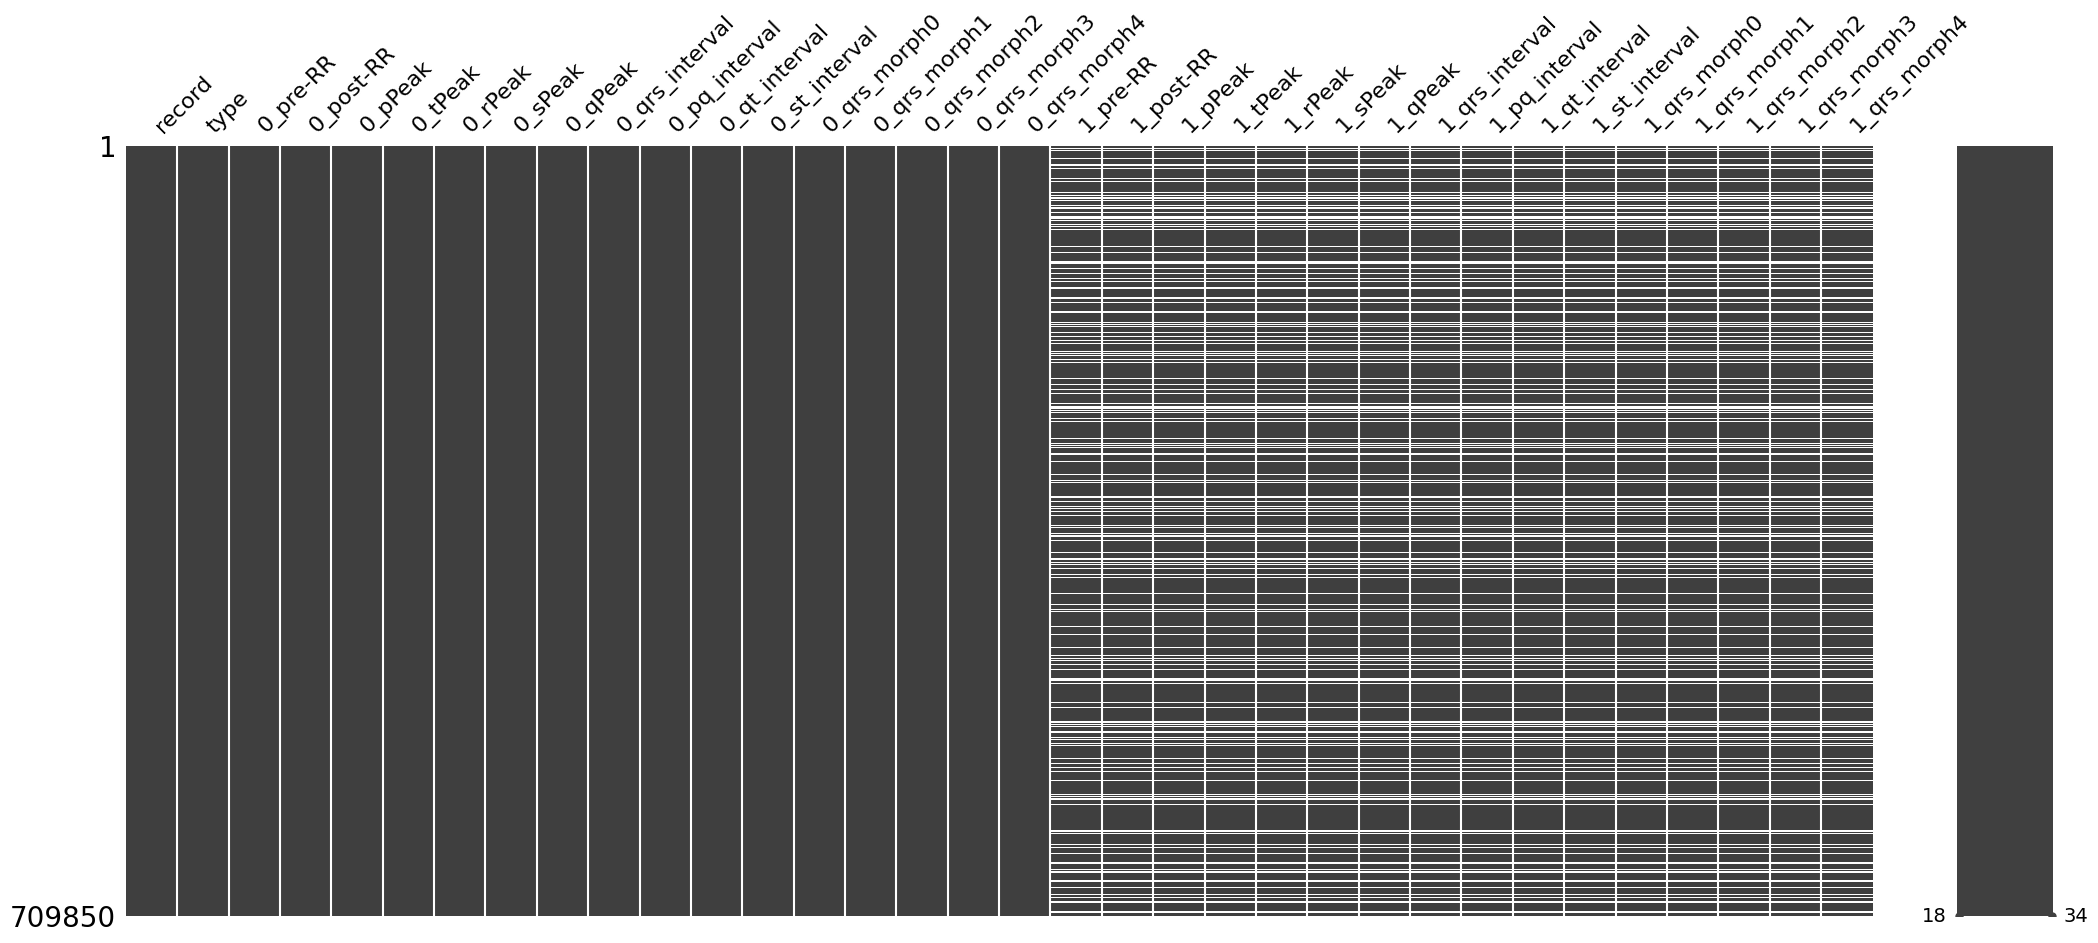

In [14]:
msno.matrix(df)

For now, we'll just drop those missing values

In [15]:
df = df.dropna()

In [16]:
df_desc = df.describe().T
df_desc[['mean', 'std', 'min', 'max']]

,mean,std,min,max
0_pre-RR,190.627091,80.918465,2.000000,2228.000000
0_post-RR,190.600554,82.173796,0.000000,10964.000000
0_pPeak,0.044637,0.180339,-4.208601,10.565904
0_tPeak,0.288630,0.610678,-7.959463,4.633166
0_rPeak,0.637717,0.793011,-7.113196,4.598265
0_sPeak,-0.460256,0.742339,-7.971319,4.018918
0_qPeak,-0.130544,0.297892,-7.113196,3.129033
0_qrs_interval,18.883151,13.778675,0.000000,170.000000
0_pq_interval,8.657865,7.781476,1.000000,150.000000
0_qt_interval,46.118175,37.142649,3.000000,334.000000


In [17]:
obj_features = df.select_dtypes(include='object')
for col in obj_features.columns:
    print(f"Column: {col}")
    print(obj_features[col].value_counts())

Column: record
record
49.0    65910
31.0    50104
34.0    20235
36.0    18065
32.0    14446
        ...  
123      1221
I61      1166
811      1141
30.0      168
35.0       53
Name: count, Length: 208, dtype: int64
Column: type
type
N       515636
VEB      38610
SVEB     14792
F          992
Q          117
Name: count, dtype: int64


## Check balance of the dataset

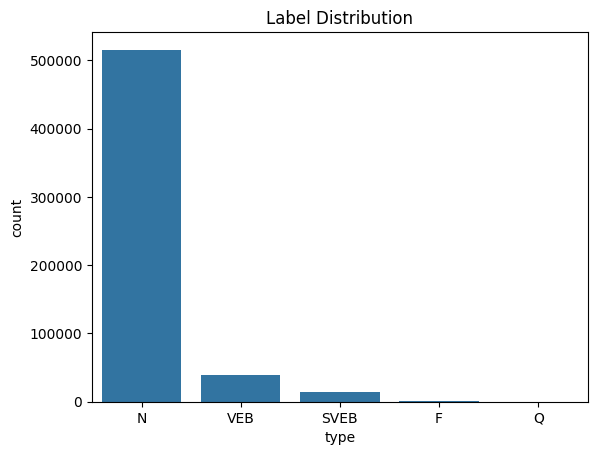

In [18]:
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Label Distribution')
plt.show()

This dataset is highly imbalanced

### Map target label to correspond code

In [19]:
label_map = {
    'F': 0, 
    'N': 1,
    'Q': 2,
    'SVEB': 3,
    'VEB': 4
}

df['label'] = df['type'].map(label_map)
df.head()

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,label
id,,,,,,,,,,,,,,,,,,,,,
1,I13,N,256.0,257.0,-0.025436,-0.369672,1.529989,-0.619057,-0.079256,17.0,...,5.0,2.0,15.0,8.0,-0.036850,-0.175291,-0.343045,-0.511080,-0.644588,1
2,867,N,91.0,101.0,0.005207,0.205958,-0.005508,-0.512249,-0.005508,4.0,...,18.0,1.0,23.0,4.0,-0.062579,0.034085,0.166282,0.677930,-0.205569,1
3,106,N,291.0,287.0,0.347613,1.470143,1.424123,1.424123,-0.090802,21.0,...,2.0,5.0,15.0,8.0,-0.052524,-0.052524,-0.052524,-0.050269,-0.050269,1
4,49.0,N,274.0,278.0,0.023990,0.878232,0.815362,0.815362,-0.032605,27.0,...,1.0,5.0,14.0,8.0,-0.107051,-0.107051,-0.107051,-0.107051,-0.107051,1
5,34.0,N,242.0,242.0,0.092220,1.011302,-0.078682,-0.078682,-0.078682,0.0,...,19.0,3.0,27.0,5.0,-0.010008,0.004223,0.115988,0.164468,-0.013203,1


## Testset and Submission Sample

In [20]:
test_df = pd.read_csv(DATA_PATH / 'test.csv')
sample_submission = pd.read_csv(DATA_PATH / 'sample_submission.csv')

In [21]:
test_df

,id,record,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,1,32.0,190.0,188.0,0.107335,0.432600,-0.022734,-0.022734,-0.070402,14.0,...,-0.173336,5.0,19.0,41.0,17.0,-0.173336,-0.238194,-0.310729,-0.382699,-0.442381
1,2,32.0,174.0,170.0,0.078369,0.300423,-0.039887,-0.039887,-0.076791,9.0,...,-0.076935,8.0,13.0,39.0,18.0,-0.076935,-0.113860,-0.236910,-0.322416,-0.505188
2,3,36.0,270.0,274.0,0.041601,0.603728,0.212613,0.212613,0.035339,6.0,...,0.015168,15.0,10.0,37.0,12.0,0.015168,0.019182,0.028516,-0.022568,-0.296055
3,4,205,266.0,268.0,0.010179,0.943830,0.913318,0.913318,-0.018720,10.0,...,-0.037889,6.0,3.0,18.0,9.0,-0.037889,-0.060003,-0.089765,-0.124220,-0.158533
4,5,49.0,268.0,272.0,0.021818,0.738181,0.725056,0.725056,-0.044609,30.0,...,-0.119538,0.0,6.0,13.0,7.0,-0.119538,-0.119538,-0.119538,-0.119538,-0.119538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142670,142671,893,85.0,50.0,0.027665,0.055184,0.481523,-0.506605,0.009776,7.0,...,-0.101602,3.0,6.0,14.0,5.0,-0.101602,-0.101602,-0.237012,-0.237012,-0.380699
142671,142672,34.0,238.0,252.0,0.117850,0.994661,-0.052910,-0.052910,-0.052910,0.0,...,0.011925,18.0,13.0,36.0,5.0,0.011925,0.028624,0.136607,0.167212,-0.007862
142672,142673,I66,205.0,205.0,-0.013022,-0.203857,0.909440,-0.355430,-0.071848,16.0,...,-0.002226,15.0,4.0,28.0,9.0,-0.002226,0.018706,0.105253,0.083551,-0.317240
142673,142674,200,219.0,314.0,0.136612,1.090781,-1.150501,-1.810932,-1.150501,5.0,...,-0.123690,4.0,24.0,38.0,10.0,-0.123690,-0.123690,-0.116990,-0.101722,-0.076411


In [22]:
test_df.isnull().sum().sort_values(ascending=False)

id                0
1_qrs_interval    0
1_post-RR         0
1_pPeak           0
1_tPeak           0
1_rPeak           0
1_sPeak           0
1_qPeak           0
1_pq_interval     0
record            0
1_qt_interval     0
1_st_interval     0
1_qrs_morph0      0
1_qrs_morph1      0
1_qrs_morph2      0
1_qrs_morph3      0
1_pre-RR          0
0_qrs_morph4      0
0_qrs_morph3      0
0_qrs_morph2      0
0_qrs_morph1      0
0_qrs_morph0      0
0_st_interval     0
0_qt_interval     0
0_pq_interval     0
0_qrs_interval    0
0_qPeak           0
0_sPeak           0
0_rPeak           0
0_tPeak           0
0_pPeak           0
0_post-RR         0
0_pre-RR          0
1_qrs_morph4      0
dtype: int64

All good, test set doesn't have missing values

In [23]:
sample_submission

,id,preds_res,model_info
0,1,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
1,2,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
2,3,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
3,4,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
4,5,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
...,...,...,...
142670,142671,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
142671,142672,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
142672,142673,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"
142673,142674,4,"{""flops"": ""3.721M"", ""num_parameters"": ""1.023M""}"


# Split dataset

In [24]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

## Ratio 6:2:2

In [25]:
train_size = 0.6
val_test_ratio = 0.5

X = df.drop(columns=['type', 'label', 'record'])
y = df['label']

X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, train_size=train_size, random_state=seed, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=val_test_ratio, random_state=seed, stratify=y_valtest)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [26]:
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (342088, 32), y_train shape: (342088,)
X_val shape: (114029, 32), y_val shape: (114029,)
X_test shape: (114030, 32), y_test shape: (114030,)


# Model Definition

In [27]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)   

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [28]:
train_batch_size = 128
test_batch_size = 1028

train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=test_batch_size, shuffle=False)
test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=test_batch_size, shuffle=False)

### DNN

In [29]:
class DNN(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_layers: list = [128, 64],
        output_dim: int = 5,
        dropout: float = 0.0,
        batch_norm: bool = False,
        activation: str = 'relu',
    ):
        super(DNN, self).__init__()
        self.activation = self._activation(activation)

        layers = []

        prev_dim = input_dim
        for h in hidden_layers:
            # Follow Linear -> BatchNorm (optional) -> Activation -> Dropout (optional)
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

    def _activation(self, act):
        return {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'silu': nn.SiLU(),
        }.get(act, nn.ReLU())
        

### CNN

In [30]:
class CNN(nn.Module):
    def __init__(
        self,
        input_channels: int = 1,
        input_dim: int = 32,
        conv_layers: list = [32, 64, 128],
        fc_layers: list = [128],
        output_dim: int = 5,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'leaky_relu',
        global_pool: bool = False,
    ):
        super(CNN, self).__init__()
        self.activation = self._activation(activation)

        # Convolutional layers
        conv_blocks = []
        prev_channels = input_channels
        for out_channels in conv_layers:
            # Follow conv -> batchnorm (optional) -> activation -> maxpool
            conv_blocks.append(nn.Conv1d(prev_channels, out_channels, kernel_size, stride, padding))
            if batch_norm:
                conv_blocks.append(nn.BatchNorm1d(out_channels))
            conv_blocks.append(self.activation)
            conv_blocks.append(nn.MaxPool1d(2))
            prev_channels = out_channels

        # Global average pooling to tremendously reduce number of parameters
        if global_pool:
            conv_blocks.append(nn.AdaptiveAvgPool1d(1))

        self.feature_extractor = nn.Sequential(*conv_blocks)

        # Compute the immediate output size after conv layers
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_dim)
            conv_output = self.feature_extractor(dummy)
            conv_output_size = conv_output.view(1, -1).size(1)

        # Fully connected layers
        fc_layers = [conv_output_size] + fc_layers + [output_dim]
        fc_blocks = []
        for i in range(len(fc_layers) - 2):
            fc_blocks.append(nn.Linear(fc_layers[i], fc_layers[i+1]))
            # if batch_norm:
            #     fc_blocks.append(nn.BatchNorm1d(fc_layers[i+1]))
            fc_blocks.append(self.activation)
            if dropout > 0:
                fc_blocks.append(nn.Dropout(dropout))
        # Final output layer
        fc_blocks.append(nn.Linear(fc_layers[-2], fc_layers[-1]))

        self.fc = nn.Sequential(*fc_blocks)


    def forward(self, x):
        x = x.unsqueeze(1) # (B, input_dim) -> (B, 1, input_dim)
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x
    
    def _activation(self, activation):
        return {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'silu': nn.SiLU()
        }.get(activation, nn.ReLU())


### Implement FocalLoss to handle imbalanced dataset

In [31]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        logpt = -self.ce(inputs, targets)
        pt = torch.exp(logpt)
        focal_loss = -self.alpha * (1 - pt) ** self.gamma * logpt

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## Trainer

In [32]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        scheduler=False,
        lr=0.001,
        early_stopping=True,
        early_stopping_patience=5,
        device=torch.device('cpu'),
        label_smoothing=0.0,
    ):
        """
        Class for training and validating model

        Args:
            model: PyTorch model to be trained
            train_loader: DataLoader for training data
            val_loader: DataLoader for validation data
            scheduler: Whether to apply learning rate scheduler
            lr: Learning rate
            early_stopping: Whether to apply early stopping
            early_stopping_patience: Patience for early stopping
            device: Device to run the model on (cpu or cuda)
            label_smoothing: Label smoothing factor for CrossEntropyLoss
        """
        self.device = device
        self.model = model.to(self.device)

        self.train_loader = train_loader
        self.val_loader = val_loader

        # self.criterion = FocalLoss()
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

        self.scheduler = None
        if scheduler:
            self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=200, eta_min=1e-6)
            # self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.5)
            # self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            #     self.optimizer,
            #     T_0=10,
            #     T_mult=2,
            #     eta_min=1e-6
            # )

        # Early stopping
        self.early_stopping = early_stopping
        if early_stopping:
            self.early_stopping_patience = early_stopping_patience
            self.best_val_loss = float('inf')
            self.epochs_no_improve = 0
            self.best_weights = None

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'train_f1': [],
            'val_f1': [],
        }

    def train_one_epoch(self):
        """Train the model for one epoch"""
        self.model.train()
        epoch_loss, correct, total = [], 0, 0

        all_preds, all_gts = [], [] # Predictions and Ground Truths   
        for X_train, y_train in tqdm.tqdm(self.train_loader, desc="Training", leave=False):
            X_train, y_train = X_train.to(self.device), y_train.to(self.device)

            self.optimizer.zero_grad()
            y_preds = self.model(X_train)
            loss = self.criterion(y_preds, y_train)
            loss.backward()
            self.optimizer.step()

            epoch_loss.append(loss.item())

            _, preds = torch.max(y_preds.data, 1)
            total += y_train.size(0)
            correct += (preds == y_train).sum().item()

            all_preds.extend(preds.detach().cpu().numpy())
            all_gts.extend(y_train.detach().cpu().numpy())

        epoch_loss = np.mean(epoch_loss)
        epoch_acc = correct / total
        # Use weighted instead of macro for class imbalance
        epoch_f1 = f1_score(all_gts, all_preds, average='weighted', zero_division=0)

        return epoch_loss, epoch_acc, epoch_f1

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        epoch_loss, correct, total = 0.0, 0, 0
        all_preds, all_gts = [], []
        with torch.no_grad():
            for X_val, y_val in tqdm.tqdm(self.val_loader, desc="Validation", leave=False):
                X_val, y_val = X_val.to(self.device), y_val.to(self.device)

                y_preds = self.model(X_val)
                loss = self.criterion(y_preds, y_val)

                epoch_loss += loss.item() * X_val.size(0)
                _, preds = torch.max(y_preds, 1)
                total += y_val.size(0)
                correct += (preds == y_val).sum().item()

                all_preds.extend(preds.detach().cpu().numpy())
                all_gts.extend(y_val.detach().cpu().numpy())

        epoch_loss = epoch_loss / len(self.val_loader.dataset)
        epoch_acc = correct / total
        epoch_f1 = f1_score(all_gts, all_preds, average='weighted', zero_division=0)

        return epoch_loss, epoch_acc, epoch_f1

    def fit(self, epochs=10, verbose=True, saved_model_path=None):
        """
        Main training loop

        Args:
            epochs: Number of epochs to train
            verbose: Whether to print training progress
            saved_model_path: Path to save the best model weights
        """
        start_time = time.time()
        for epoch in range(epochs):
            train_loss, train_acc, train_f1 = self.train_one_epoch()
            val_loss, val_acc, val_f1 = self.validate()

            if self.scheduler:
                self.scheduler.step()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)

            # if verbose and (epoch + 1) % (epochs // 10) == 0:
            if verbose and (epoch + 1) % 10 == 0:
                print(f'EPOCH [{epoch+1}/{epochs}]'
                      f' Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}'
                      f' | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

            if self.early_stopping:
                # If improvement
                if val_loss < self.best_val_loss: 
                    self.best_val_loss = val_loss
                    self.epochs_no_improve = 0
                    self.best_weights = self.model.state_dict()
                else:
                    self.epochs_no_improve += 1
                    if self.epochs_no_improve >= self.early_stopping_patience:
                        print("Early stopping at epoch", epoch+1)
                        if self.best_weights is not None:
                            self.model.load_state_dict(self.best_weights)
                        break
        # Load best weights after training
        if self.best_weights is not None:
            self.model.load_state_dict(self.best_weights)

        # Save the best model
        if saved_model_path:
            torch.save(self.model.state_dict(), saved_model_path)

        print(f'Training time: {time.time() - start_time:.2f}s')

        return self.history

In [33]:
@torch.no_grad()
def test(model, test_loader):
    """
    Evaluate the model on the test set
    """
    model.eval()
    correct, total = 0, 0
    all_preds, all_gts = [], []
    with torch.no_grad():
        for X_test, y_test in tqdm.tqdm(test_loader, desc='Testing', leave=False):
            X_test, y_test = X_test.to(device), y_test.to(device)
            y_preds = model(X_test)
            _, preds = torch.max(y_preds, 1)
            correct += (preds == y_test).sum().item()
            total += y_test.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_gts.extend(y_test.detach().cpu().numpy())
    
    test_acc = correct / total
    test_f1_weighted = f1_score(all_gts, all_preds, average='weighted', zero_division=0)
    test_f1_macro = f1_score(all_gts, all_preds, average='macro', zero_division=0)

    return test_acc, test_f1_weighted, test_f1_macro, all_preds, all_gts

In [34]:
def calculate_parameters(model):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return params

def estimate_flops(model, input_shape):
    """
    Estimate FLOPs for Linear and Conv2d layers only.
    Args:
        model (nn.Module): PyTorch model
        input_shape (tuple): shape of one input sample, e.g., (1, 3, 224, 224) or (1, input_dim)
    Returns:
        total_flops (int)
    """
    flops = 0

    def count_layer(layer, x_in, x_out):
        nonlocal flops
        if isinstance(layer, nn.Conv1d):
            # FLOPs for Conv1d: K * Cin * Cout * Nfeatures
            kernel_ops = layer.kernel_size[0]
            flops += kernel_ops * layer.in_channels * layer.out_channels * x_out.shape[-1]
        # Linear FLOPs: input_features * output_features
        elif isinstance(layer, nn.Linear):
            flops += layer.in_features * layer.out_features
    
    hooks = []
    for layer in model.modules():
        if isinstance(layer, (nn.Conv1d, nn.Linear)):
            hooks.append(layer.register_forward_hook(count_layer))
    
    dummy = torch.randn(input_shape)
    model.eval()
    with torch.no_grad():
        model(dummy)
    
    for hook in hooks:
        hook.remove()

    return flops

def save_model_stats(model, input_dim, save_path="model_stats.json"):
    """
    Save parameter count and estimated FLOPs to JSON (no thop needed).
    Args:
        model (nn.Module): PyTorch model
        input_dim (int or tuple): Input feature dimension or shape
        save_path (str): Output JSON path
    """
    # Create dummy input shape
    input_shape = (1, input_dim) if isinstance(input_dim, int) else (1, *input_dim)

    # Count parameters
    total_params = calculate_parameters(model)

    # Estimate FLOPs
    flops = estimate_flops(model, input_shape)

    # Format into M (millions)
    stats = {
        "flops": f"{flops/1e6:.3f}M",
        "num_parameters": f"{total_params/1e6:.3f}M"
    }
    return stats

# Training

### Hyperparameters

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

learning_rate = 0.0005
epochs = 300
batchnorm = False
dnn_layers = [8, 16]
activation = 'silu'
dropout = 0.0
early_stopping = True
early_stopping_patience = 10
output_dim = 5
scheduler = True
label_smoothing = 0.0

In [36]:
sample_X, sample_y = next(iter(train_loader))
sample_X, sample_y = sample_X.to(device), sample_y.to(device)
print(f'sample_X shape: {sample_X.shape}\nsample_y shape: {sample_y.shape}')

sample_X shape: torch.Size([128, 32])
sample_y shape: torch.Size([128])


### Training model

In [37]:
dnn_model = DNN(
    input_dim=sample_X.shape[1],
    hidden_layers=dnn_layers,
    output_dim=output_dim,
    dropout=dropout,
    batch_norm=batchnorm,
    activation=activation,
)

# dnn_model = CNN(
#     input_dim=sample_X.shape[1],
#     conv_layers=[8, 15],
#     fc_layers=[],
#     output_dim=output_dim,
#     dropout=dropout,
#     batch_norm=batchnorm,
#     activation=activation,
#     global_pool=True,
# )
dnn_stats = save_model_stats(dnn_model, input_dim=sample_X.shape[1])
print(dnn_stats)

{'flops': '0.000M', 'num_parameters': '0.000M'}


In [38]:
num_params = calculate_parameters(dnn_model)
print(f'DNN Model Parameters: {num_params}')

DNN Model Parameters: 493


Validate if DNN can successfully run

In [39]:
with torch.no_grad():
    dnn_model = dnn_model.to(device)
    output_DNN = dnn_model(sample_X)
    print("DNN Output shape:", output_DNN.shape)

DNN Output shape: torch.Size([128, 5])


In [40]:
SUBMISSION_DIR = Path('./submissions/latest')
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

dnn_trainer = Trainer(
    model=dnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    lr=learning_rate,
    early_stopping=early_stopping,
    early_stopping_patience=early_stopping_patience,
    label_smoothing=label_smoothing,
    device=device
)
history_dnn = dnn_trainer.fit(epochs=epochs, verbose=True, saved_model_path=SUBMISSION_DIR / 'model_weights.pth')
history_dnn = pd.DataFrame(dnn_trainer.history)

EPOCH [10/300] Train Loss: 0.1122, Train Acc: 0.9661 | Val Loss: 0.1135, Val Acc: 0.9670


EPOCH [20/300] Train Loss: 0.0987, Train Acc: 0.9708 | Val Loss: 0.1007, Val Acc: 0.9708


EPOCH [30/300] Train Loss: 0.0924, Train Acc: 0.9727 | Val Loss: 0.0946, Val Acc: 0.9726


EPOCH [40/300] Train Loss: 0.0896, Train Acc: 0.9736 | Val Loss: 0.0919, Val Acc: 0.9732


EPOCH [50/300] Train Loss: 0.0881, Train Acc: 0.9740 | Val Loss: 0.0906, Val Acc: 0.9740


EPOCH [60/300] Train Loss: 0.0873, Train Acc: 0.9742 | Val Loss: 0.0901, Val Acc: 0.9740


EPOCH [70/300] Train Loss: 0.0866, Train Acc: 0.9743 | Val Loss: 0.0895, Val Acc: 0.9741


EPOCH [80/300] Train Loss: 0.0860, Train Acc: 0.9744 | Val Loss: 0.0896, Val Acc: 0.9740


EPOCH [90/300] Train Loss: 0.0857, Train Acc: 0.9744 | Val Loss: 0.0889, Val Acc: 0.9742


Early stopping at epoch 98
Training time: 143.95s


# Evaluation

In [41]:
def plot_loss(loss_df, save_dir):
    save_dir = save_dir / 'loss_plots'
    save_dir.mkdir(parents=True, exist_ok=True)

    epochs = range(1, len(loss_df) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(6*2, 5))

    axes[0].plot(epochs, loss_df['train_loss'], label='Train Loss')
    axes[0].plot(epochs, loss_df['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(loc='upper right')

    axes[1].plot(epochs, loss_df['train_acc'], label='Train Accuracy')
    axes[1].plot(epochs, loss_df['val_acc'], label='Val Accuracy')
    axes[1].plot(epochs, loss_df['train_f1'], label='Train F1', linestyle='--')
    axes[1].plot(epochs, loss_df['val_f1'], label='Val F1', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(save_dir / f'train_loss.png')

In [42]:
def conf_mat_report(y_gts, y_preds):
    print(classification_report(y_gts, y_preds, target_names=label_map.keys(), zero_division=0))
    conf_mat = confusion_matrix(y_gts, y_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_map.keys(), 
                yticklabels=label_map.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [43]:
def calculate_score(model, y_true, y_pred, beta=2):
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_beta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)
    num_params = calculate_parameters(model)
    acc_score = accuracy_score(y_true, y_pred)
    print(f'\nNumber of Parameters: {num_params}')
    print(f'Accuracy Score: {acc_score}')
    print(f'F1 Score (Beta={beta}): {f1_beta}')

    score = 0.7 * acc_score + 0.3 * f1_beta - 0.02 * np.log(num_params)
    print(f'Score: {score}\n')
    return score

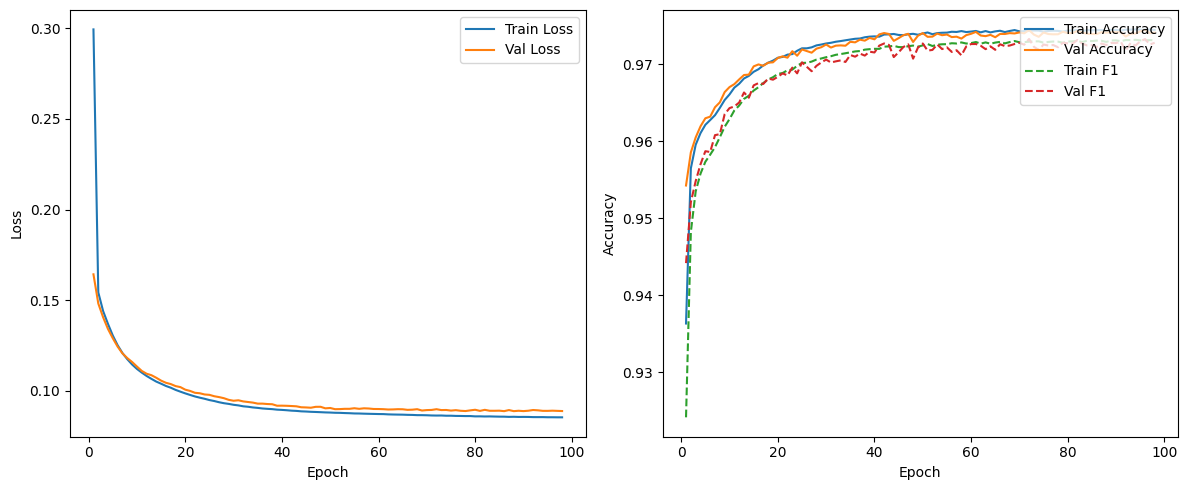

In [44]:
plot_loss(history_dnn, Path('./results/DNN'))

DNN Test Accuracy: 0.9740, Weighted F1: 0.9728, Macro F1: 0.5848
              precision    recall  f1-score   support

           F       0.82      0.23      0.35       199
           N       0.98      0.99      0.99    103127
           Q       0.00      0.00      0.00        23
        SVEB       0.73      0.62      0.67      2959
         VEB       0.92      0.90      0.91      7722

    accuracy                           0.97    114030
   macro avg       0.69      0.55      0.58    114030
weighted avg       0.97      0.97      0.97    114030



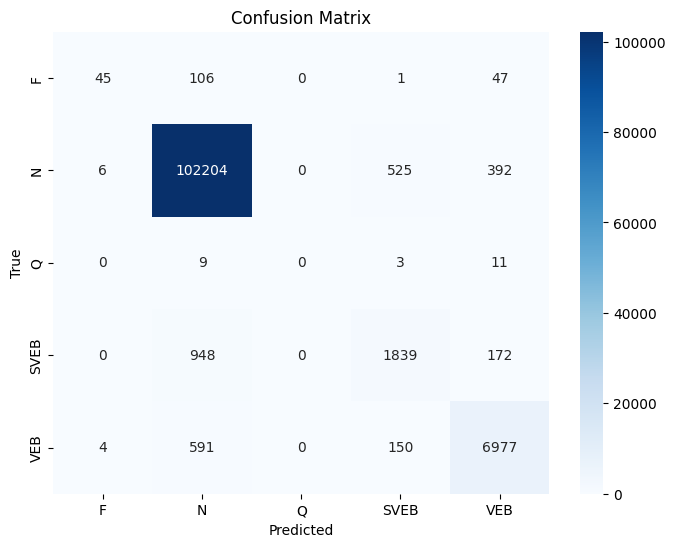

In [45]:
test_acc, test_f1_weighted, test_f1_macro, dnn_y_preds, dnn_y_gts = test(dnn_model, test_loader)
print(f'DNN Test Accuracy: {test_acc:.4f}, Weighted F1: {test_f1_weighted:.4f}, Macro F1: {test_f1_macro:.4f}')
conf_mat_report(dnn_y_gts, dnn_y_preds)

In [46]:
dnn_score = calculate_score(dnn_model, dnn_y_gts, dnn_y_preds, beta=2)


Number of Parameters: 493
Accuracy Score: 0.9739980706831536
F1 Score (Beta=2): 0.9737056432791106
Score: 0.8499001589810868



In [47]:
test_data = test_df.drop(columns=['record', 'id'])
test_data = scaler.transform(test_data)
test_data = torch.tensor(test_data, dtype=torch.float32)
real_test_loader = DataLoader(test_data, batch_size=test_batch_size, shuffle=False)

In [48]:
@torch.no_grad()
def final_test(model, test_loader):
    """
    Evaluate the model on the test set (without label)
    It's for generating submission predictions
    """
    model.eval()
    with torch.no_grad():
        all_preds = []
        for X_test in tqdm.tqdm(test_loader, desc='Final Testing', leave=False):
            X_test = X_test.to(device)
            y_preds = model(X_test)
            _, preds = torch.max(y_preds, 1)
            all_preds.extend(preds.detach().cpu().numpy())
    return all_preds

In [49]:
sample_test_X = next(iter(real_test_loader))
sample_test_X = sample_test_X.to(device)
print(f'sample_test_X shape: {sample_test_X.shape}')

sample_test_X shape: torch.Size([1028, 32])


# Save submission

In [50]:
test_preds = final_test(dnn_model, real_test_loader)

In [51]:
preds = pd.DataFrame({
    "id": test_df['id'],
    "preds_res": test_preds,
    "model_info": json.dumps(dnn_stats)
})
preds.to_csv(SUBMISSION_DIR / "submission.csv", index=False)

In [52]:
submission = pd.read_csv(SUBMISSION_DIR / "submission.csv")
submission

,id,preds_res,model_info
0,1,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
1,2,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
2,3,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
3,4,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
4,5,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
...,...,...,...
142670,142671,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
142671,142672,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
142672,142673,1,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"
142673,142674,4,"{""flops"": ""0.000M"", ""num_parameters"": ""0.000M""}"


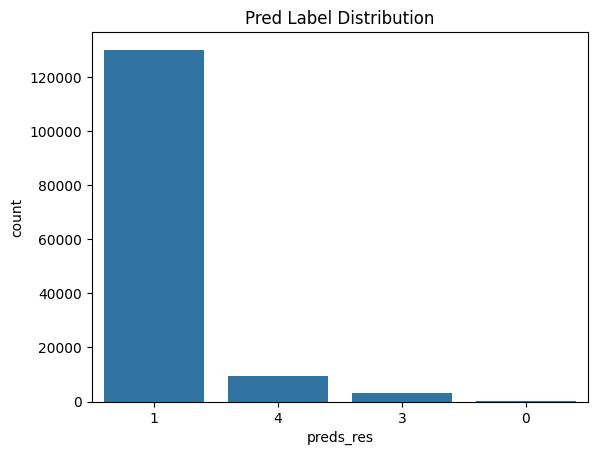

In [57]:
sns.countplot(data=submission, x='preds_res', order=submission['preds_res'].value_counts().index)
plt.title('Pred Label Distribution')
plt.show()